# Augmented Trajectory Analysis

Plots success rate and action accuracy faceted by ISO transform type (5 panels: original, ReflectEnv, RotateEnv, StartGoalSwap, TransposeEnv).

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path("../../../..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from analysis.full_obs_trajectory_analysis import setup_paper_style

In [2]:
OUTPUT_DIR = Path(".").resolve()

BASE_CSV = OUTPUT_DIR.parent / "multiple_trajectories" / "coin_trajectory_metrics_multiple_trajectories.csv"
AUG_CSV  = OUTPUT_DIR / "coin_trajectory_metrics_augmented_trajectories.csv"

df_base = pd.read_csv(BASE_CSV)
df_base["transform_type"] = "base"

df_aug = pd.read_csv(AUG_CSV)

df = pd.concat([df_base, df_aug], ignore_index=True)

print(f"Base rows:      {len(df_base)}")
print(f"Augmented rows: {len(df_aug)}")
print(f"Transforms:     {sorted(df['transform_type'].unique())}")

Base rows:      5
Augmented rows: 5
Transforms:     ['ReflectEnv', 'RotateEnv', 'StartGoalSwap', 'TransposeEnv', 'base']


In [3]:
TRANSFORM_ORDER = ["base", "ReflectEnv", "RotateEnv", "StartGoalSwap", "TransposeEnv"]
TRANSFORM_LABELS = {
    "base":          "Original",
    "ReflectEnv":    "Reflect",
    "RotateEnv":     "Rotate",
    "StartGoalSwap": "Start/Goal Swap",
    "TransposeEnv":  "Transpose",
}

## Success Rate — faceted by transform

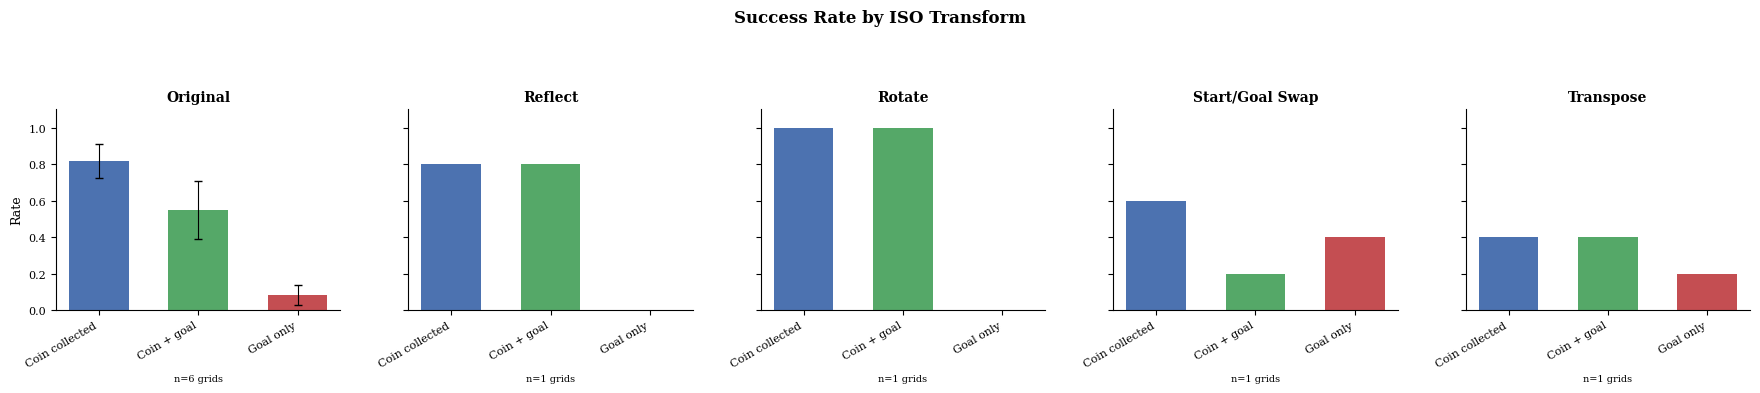

In [4]:
setup_paper_style()

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

success_cols = {
    "Coin collected": "coin_collected_rate",
    "Coin + goal":    "full_success_rate",
    "Goal only":      "goal_only_rate",
}

x = np.arange(len(success_cols))
width = 0.6
colors = ["#4C72B0", "#55A868", "#C44E52"]

for ax, transform in zip(axes, TRANSFORM_ORDER):
    subset = df[df["transform_type"] == transform]
    means = [subset[col].mean() for col in success_cols.values()]
    sems  = [subset[col].sem()  for col in success_cols.values()]

    bars = ax.bar(x, means, width, color=colors, yerr=sems, capsize=3, error_kw=dict(linewidth=0.8))

    ax.set_title(TRANSFORM_LABELS[transform], fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(list(success_cols.keys()), rotation=30, ha="right", fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlabel(f"n={len(subset)} grids", fontsize=7)

axes[0].set_ylabel("Rate", fontsize=9)
fig.suptitle("Success Rate by ISO Transform", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()

out_png = OUTPUT_DIR / "png" / "success_rate_by_transform.png"
out_pdf = OUTPUT_DIR / "pdf" / "success_rate_by_transform.pdf"
out_png.parent.mkdir(exist_ok=True)
out_pdf.parent.mkdir(exist_ok=True)
fig.savefig(out_png, dpi=150, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

## Action Accuracy — faceted by transform

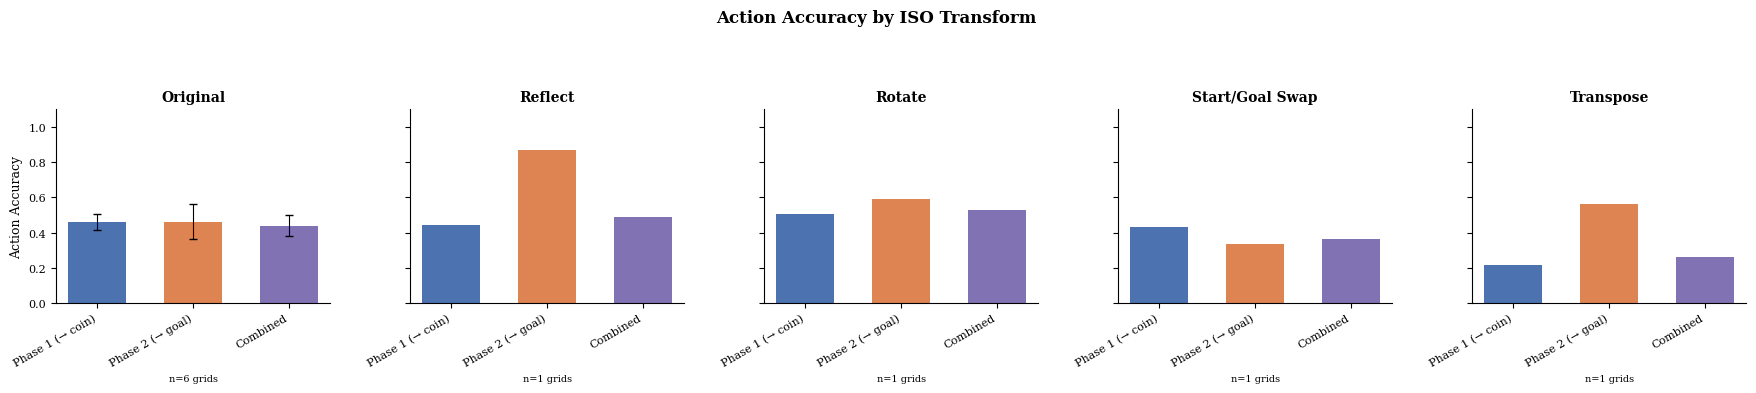

In [5]:
setup_paper_style()

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

accuracy_cols = {
    "Phase 1 (→ coin)": "mean_action_accuracy_phase1",
    "Phase 2 (→ goal)": "mean_action_accuracy_phase2",
    "Combined":         "mean_action_accuracy",
}

x = np.arange(len(accuracy_cols))
colors = ["#4C72B0", "#DD8452", "#8172B3"]

for ax, transform in zip(axes, TRANSFORM_ORDER):
    subset = df[df["transform_type"] == transform]
    means = [subset[col].mean() for col in accuracy_cols.values()]
    sems  = [subset[col].sem()  for col in accuracy_cols.values()]

    ax.bar(x, means, width, color=colors, yerr=sems, capsize=3, error_kw=dict(linewidth=0.8))

    ax.set_title(TRANSFORM_LABELS[transform], fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(list(accuracy_cols.keys()), rotation=30, ha="right", fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlabel(f"n={len(subset)} grids", fontsize=7)

axes[0].set_ylabel("Action Accuracy", fontsize=9)
fig.suptitle("Action Accuracy by ISO Transform", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()

out_png = OUTPUT_DIR / "png" / "action_accuracy_by_transform.png"
out_pdf = OUTPUT_DIR / "pdf" / "action_accuracy_by_transform.pdf"
fig.savefig(out_png, dpi=150, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

## Summary table

In [6]:
summary_cols = [
    "coin_collected_rate", "full_success_rate", "goal_only_rate",
    "mean_action_accuracy", "mean_action_accuracy_phase1", "mean_action_accuracy_phase2",
    "spl",
]

summary = (
    df.groupby("transform_type")[summary_cols]
    .mean()
    .reindex(TRANSFORM_ORDER)
    .rename(index=TRANSFORM_LABELS)
    .round(3)
)
summary

,coin_collected_rate,full_success_rate,goal_only_rate,mean_action_accuracy,mean_action_accuracy_phase1,mean_action_accuracy_phase2,spl
transform_type,,,,,,,
Original,0.817,0.55,0.083,0.439,0.460,0.462,0.258
Reflect,0.800,0.80,0.000,0.487,0.444,0.867,0.336
Rotate,1.000,1.00,0.000,0.527,0.506,0.593,0.376
Start/Goal Swap,0.600,0.20,0.400,0.364,0.432,0.337,0.108
Transpose,0.400,0.40,0.200,0.260,0.216,0.560,0.141
